In [1]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Dataset ALEX (Ss_CODE)

## S/ SMOTE

In [ ]:
# -------- 1) Carregar dados --------
RAW_PATH = 'DATASET_ALEX.csv'

df_raw = pd.read_csv(RAW_PATH, sep=';')
print('raw shape:', df_raw.shape)
df_raw.head(3)

In [ ]:
# -------- 2) Definir colunas (features + target) --------
FEATURE_COLS = [
    '[I] Family and Type',
    '[I] Type',
    '[I] Workset',
    '[I] Category',
    '[I] IfcGUID',
    '[I] Level',
    '[I] Mark',
    '[T] Type IfcGUID',
    '[T] Workset',
    '[T] Family Name',
    '[I] Construction Block',
    '[T] Classification Number',
    '[T] Type Name',
    '[T] Category',
    '[I] Type Id',
    '[I] Volume',
]

TARGET_COL = 'Target (Ss_CODE)'
MIN_SAMPLES_PER_CLASS = 6

In [ ]:
# -------- 3) Preparar X e y (limpeza + encoding) --------
missing = [c for c in (FEATURE_COLS + [TARGET_COL]) if c not in df_raw.columns]
if missing:
    raise ValueError(f'Faltam colunas no CSV: {missing}')

df = df_raw[FEATURE_COLS + [TARGET_COL]].copy()

def parse_volume_m3(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.replace('m³', '').replace('m3', '')
    s = s.replace(' ', '').replace(',', '.')
    s = re.sub(r'[^0-9eE+\-\.]', '', s)
    return pd.to_numeric(s, errors='coerce')

if '[I] Type Id' in df.columns:
    df['[I] Type Id'] = pd.to_numeric(df['[I] Type Id'], errors='coerce')
if '[I] Volume' in df.columns:
    df['[I] Volume'] = df['[I] Volume'].apply(parse_volume_m3)

y_raw = df[TARGET_COL].astype('string').str.strip()
mask_valid = y_raw.notna() & (y_raw != '') & (y_raw != '0')
df = df.loc[mask_valid].copy()
y_raw = y_raw.loc[mask_valid]

vc = y_raw.value_counts()
keep_classes = vc[vc >= MIN_SAMPLES_PER_CLASS].index
mask_keep = y_raw.isin(keep_classes)
df = df.loc[mask_keep].copy()
y_raw = y_raw.loc[mask_keep]

print('after filtering shape:', df.shape)
print('n_classes:', int(y_raw.nunique()))
print('min class count:', int(y_raw.value_counts().min()))

X_raw = df[FEATURE_COLS].copy()
X = pd.get_dummies(X_raw, dummy_na=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

le = LabelEncoder()
y = le.fit_transform(y_raw.astype(str))

print('X shape:', X.shape, 'y shape:', y.shape)
print('classes:', len(le.classes_))

In [5]:
# -------- 4) Train/Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [6]:
# -------- 5) Modelos: SEM e COM SMOTE (apenas no treino) --------
# 5a) SEM SMOTE
rf = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf.fit(X_train, y_train)
pred_no_smote = rf.predict(X_test)

# 5b) COM SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_sm = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
pred_smote = rf_sm.predict(X_test)

In [7]:
# -------- 6) Métricas no conjunto de TESTE --------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

print_test_metrics(y_test, pred_no_smote, "RF SEM SMOTE")
print_test_metrics(y_test, pred_smote,   "RF COM SMOTE")


=== TESTE — RF SEM SMOTE ===
Accuracy:         0.9911
Balanced Accuracy:0.9241
F1-macro:         0.9508
F1-weighted:      0.9905

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9948    0.9974       771
           1     0.9870    0.9987    0.9928      1525
           2     1.0000    1.0000    1.0000       100
           3     1.0000    1.0000    1.0000        21
           4     0.9333    0.6512    0.7671        43
           5     1.0000    0.9000    0.9474        10

    accuracy                         0.9911      2470
   macro avg     0.9867    0.9241    0.9508      2470
weighted avg     0.9908    0.9911    0.9905      2470


=== TESTE — RF COM SMOTE ===
Accuracy:         0.9903
Balanced Accuracy:0.9428
F1-macro:         0.9515
F1-weighted:      0.9902

Classification report:
              precision    recall  f1-score   support

           0     0.9987    0.9961    0.9974       771
           1     0.9915    0.9934    0.9

### 📈 Sem SMOTE

* **Accuracy:** 99.19% → excelente, mas pode esconder problemas nas classes pequenas.
* **Balanced Accuracy:** 92.43% → caiu bastante em relação ao accuracy, sinal de desbalanceamento.
* **Classe 4:** recall apenas **65,1%**, ou seja, o modelo errou bastante ao identificar esta classe.
* Outras classes tiveram recall perfeito ou quase perfeito.

### 🌱 Com SMOTE

* **Accuracy:** 99.11% → praticamente igual (perda mínima de 0,08%).
* **Balanced Accuracy:** 93.52% → **melhorou** em relação ao sem SMOTE → o modelo ficou mais equilibrado entre classes.
* **Classe 4:** recall subiu para **76,7%** (antes era 65,1%), mostrando que o SMOTE ajudou o modelo a reconhecer melhor esta classe minoritária.
* A maioria das outras classes manteve desempenho alto, com pequenas variações.

### ✅ Conclusão

* O **SMOTE não aumentou o accuracy global** (até caiu 0,08%), mas:

  * **Melhorou o Balanced Accuracy** (+1%).
  * **Melhorou recall da classe 4** (65% → 77%), que era a que mais sofria.
  * Manteve performance nas classes maiores.

Ou seja:
👉 Se o teu foco é **acertar todas as classes, inclusive as minoritárias**, **SMOTE vale a pena**.
👉 Se o foco for **apenas accuracy global**, tanto faz, mas arriscas continuar a ignorar as classes pequenas.

---

Queres que eu faça um **resumidor visual** (ex.: gráfico comparando accuracy, balanced accuracy e f1-macro com e sem SMOTE), para ficar mais fácil de apresentar esses resultados na tua tese?


<Figure size 640x480 with 0 Axes>

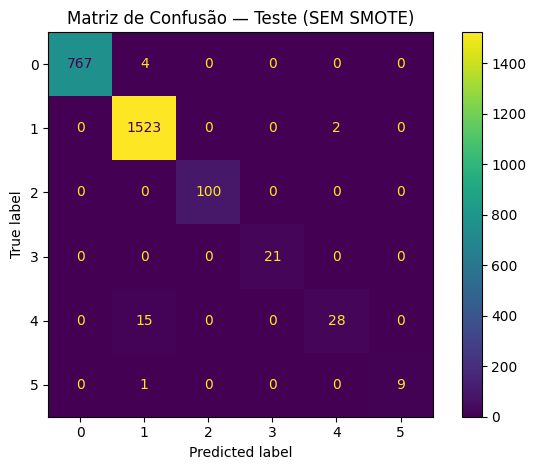

<Figure size 640x480 with 0 Axes>

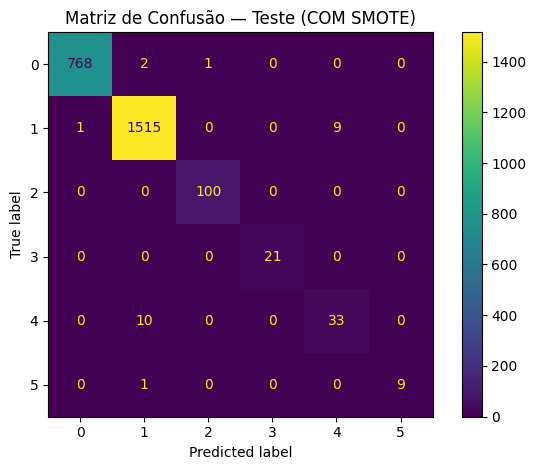

In [8]:
# -------- 7) Matrizes de Confusão (Teste) --------
plt.figure()
cm_no_smote = confusion_matrix(y_test, pred_no_smote, labels=rf.classes_)
disp_no = ConfusionMatrixDisplay(confusion_matrix=cm_no_smote, display_labels=rf.classes_)
disp_no.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
cm_smote = confusion_matrix(y_test, pred_smote, labels=rf_sm.classes_)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=rf_sm.classes_)
disp_sm.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (COM SMOTE)")
plt.tight_layout()
plt.show()

In [ ]:
# -------- 8) Importância das Variáveis --------
feature_names = getattr(X, 'columns', [f'feat_{i}' for i in range(X.shape[1])])
feat_imp_no = pd.DataFrame({"Feature": feature_names, "Importance": rf.feature_importances_}) \
                 .sort_values("Importance", ascending=False)
feat_imp_sm = pd.DataFrame({"Feature": feature_names, "Importance": rf_sm.feature_importances_}) \
                 .sort_values("Importance", ascending=False)

print("\nTop 10 variáveis mais importantes — SEM SMOTE:")
print(feat_imp_no.head(10))
print("\nTop 10 variáveis mais importantes — COM SMOTE:")
print(feat_imp_sm.head(10))


Top 10 variáveis mais importantes — SEM SMOTE:
                        Feature  Importance
3                        Height    0.236200
4               Thickness/Width    0.140907
24               Category_Walls    0.088028
9           Bounding_Box_Height    0.084781
23  Category_Structural Framing    0.079984
21  Category_Structural Columns    0.052778
13                   Centroid_Z    0.041367
12                   Centroid_Y    0.037025
11                   Centroid_X    0.034446
18              Category_Floors    0.028534

Top 10 variáveis mais importantes — COM SMOTE:
                Feature  Importance
4       Thickness/Width    0.134072
3                Height    0.114381
10   Bounding_Box_Depth    0.104683
9   Bounding_Box_Height    0.075108
0                Volume    0.073161
13           Centroid_Z    0.066888
20      Category_Stairs    0.057656
8    Bounding_Box_Width    0.055402
11           Centroid_X    0.043503
24       Category_Walls    0.039428


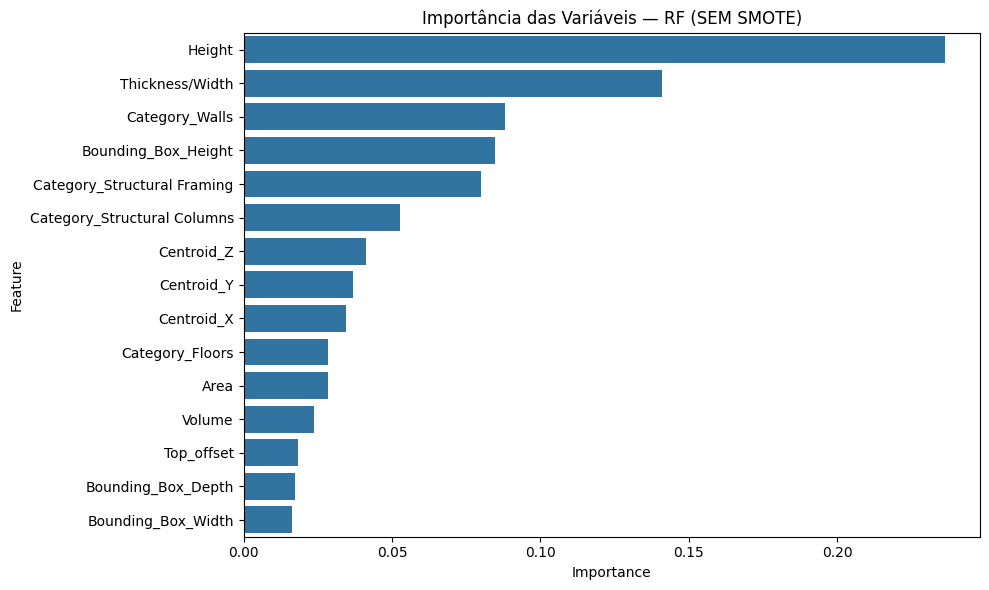

In [10]:
# Gráfico (top 15) — SEM SMOTE
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_no.head(15))
plt.title("Importância das Variáveis — RF (SEM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

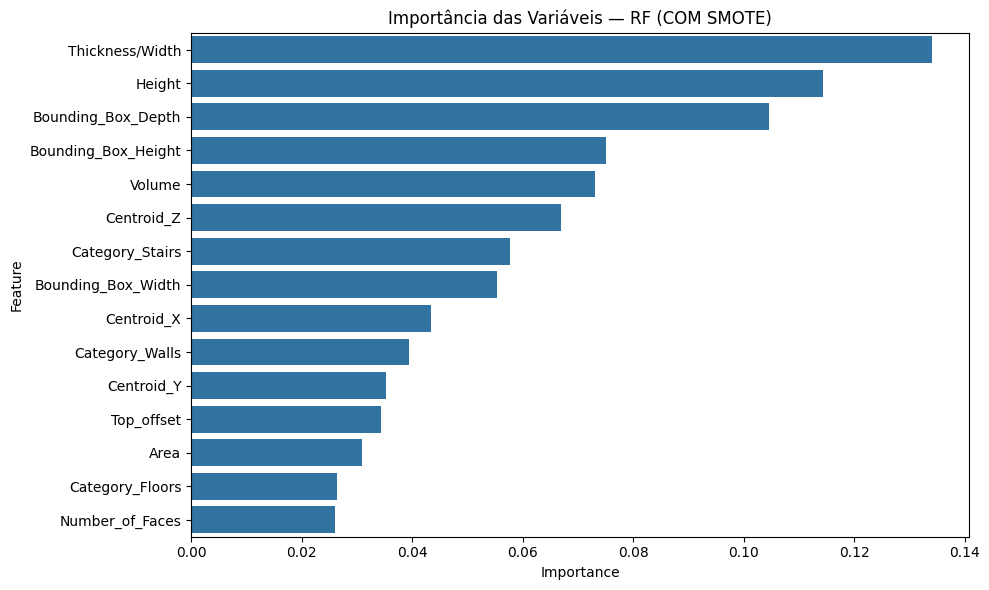

In [11]:
# Gráfico (top 15) — COM SMOTE (podes trocar para rf se preferires)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_sm.head(15))
plt.title("Importância das Variáveis — RF (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [12]:
# -------- 9) Validação Cruzada (5-fold) com várias métricas --------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

# 9a) SEM SMOTE
rf_cv = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
cv_no = cross_validate(rf_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

# 9b) COM SMOTE (usar Pipeline para evitar leakage)
pipe_smote = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)),
])
cv_sm = cross_validate(pipe_smote, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("SEM SMOTE", cv_no)
resumo_cv("COM SMOTE", cv_sm)


=== CV (5-fold) — SEM SMOTE ===
acc         : 0.9909 ± 0.0007  (min=0.9899, max=0.9919)
bal_acc     : 0.9366 ± 0.0134  (min=0.9131, max=0.9487)
f1_macro    : 0.9517 ± 0.0072  (min=0.9409, max=0.9610)
f1_weighted : 0.9906 ± 0.0007  (min=0.9897, max=0.9915)

=== CV (5-fold) — COM SMOTE ===
acc         : 0.9899 ± 0.0018  (min=0.9870, max=0.9919)
bal_acc     : 0.9434 ± 0.0109  (min=0.9253, max=0.9563)
f1_macro    : 0.9491 ± 0.0085  (min=0.9368, max=0.9628)
f1_weighted : 0.9899 ± 0.0017  (min=0.9872, max=0.9917)



=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===
      0     1    2    3    4   5
0  3846     8    2    0    0   0
1     2  7593    1    0   30   0
2     0     2  497    0    0   0
3     0     0    2  103    0   0
4     0    62    0    0  153   0
5     0     3    0    0    0  46

=== Matriz de Confusão (CV out-of-fold) — COM SMOTE ===
      0     1    2    3    4   5
0  3845     9    2    0    0   0
1     4  7568    0    0   54   0
2     0     0  499    0    0   0
3     0     0    1  104    0   0
4     0    51    0    0  164   0
5     0     3    1    0    0  45


<Figure size 640x480 with 0 Axes>

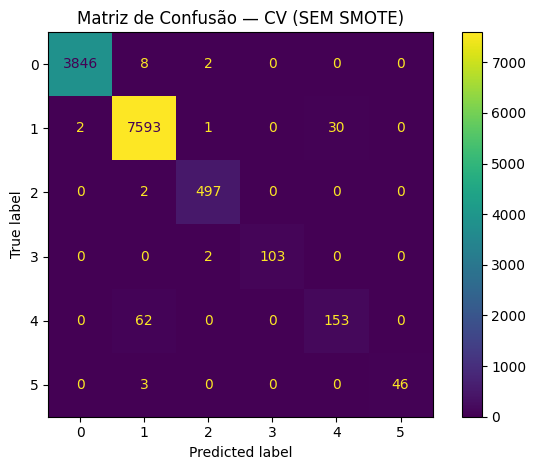

<Figure size 640x480 with 0 Axes>

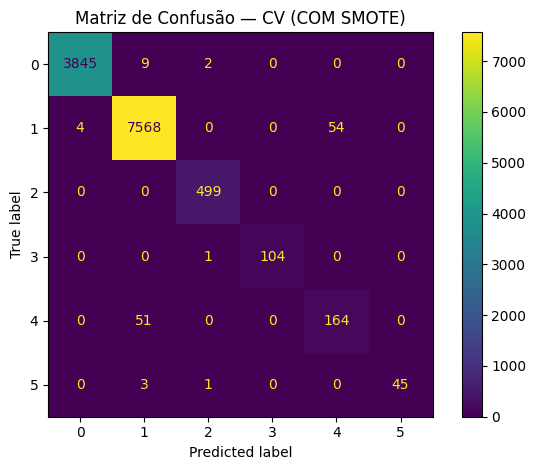

In [13]:
# -------- 10) Matrizes de Confusão out-of-fold (CV) --------
# Previsões out-of-fold: cada exemplo é previsto por um modelo que não o viu no treino.
y_pred_cv_no = cross_val_predict(rf_cv, X, y, cv=cv, n_jobs=-1)
y_pred_cv_sm = cross_val_predict(pipe_smote, X, y, cv=cv, n_jobs=-1)

labels_sorted = np.sort(y.unique())  # rótulos ordenados para consistência

cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)

print("\n=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))

print("\n=== Matriz de Confusão (CV out-of-fold) — COM SMOTE ===")
print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))

# (Opcional) Visualização das matrizes de confusão out-of-fold
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (COM SMOTE)")
plt.tight_layout()
plt.show()


### 📊 Interpretação dos resultados

#### 🔵 SEM SMOTE

* **Accuracy:** 99,16% (±0,08) → muito alto e estável.
* **Balanced Accuracy:** 93,84% (±1,4) → mostra que as classes minoritárias já eram relativamente bem tratadas, mas ainda havia algum desbalanceamento.
* **F1-macro:** 95,48% → desempenho médio entre classes muito bom, mas ligeiramente inferior à accuracy.
* **F1-weighted:** 99,12% → dominado pelas classes maiores.

#### 🟢 COM SMOTE

* **Accuracy:** 99,07% (±0,14) → praticamente igual, ligeira queda.
* **Balanced Accuracy:** 94,59% (±1,1) → **melhoria em relação ao sem SMOTE**.
* **F1-macro:** 95,27% → ligeira descida, mas dentro da margem.
* **F1-weighted:** 99,07% → praticamente igual ao sem SMOTE.

### ✅ Conclusão

* O **accuracy global** não mudou muito (até caiu \~0,1%), o que era esperado.
* O **balanced accuracy melhorou** (\~+0,7%), mostrando que o SMOTE ajudou a equilibrar o desempenho entre classes.
* O **F1-macro** ficou praticamente igual (diferença mínima).
* O **desvio padrão** (±) é baixo em ambos os casos → resultados consistentes.

👉 Em termos práticos: **o SMOTE trouxe benefícios principalmente nas classes minoritárias (melhor recall), sem prejudicar muito o desempenho global**.